# Store Sales Forecasting 

**Goal:** Predict daily sales per product family and store for an Ecuadorian grocery chain.  
**Dataset:** [Kaggle - Store Sales Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)  


## 1. Setup

In [20]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import mean_squared_log_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

SEED = 42
np.random.seed(SEED)

DATA_DIR      = Path("/home/guest/Documents/ML_INTERNS/store-sales-time-series-forecasting")
TRAIN_PATH    = DATA_DIR / "train.csv"
TEST_PATH     = DATA_DIR / "test.csv"
STORES_PATH   = DATA_DIR / "stores.csv"
OIL_PATH      = DATA_DIR / "oil.csv"
HOLIDAYS_PATH = DATA_DIR / "holidays_events.csv"
TX_PATH       = DATA_DIR / "transactions.csv"
SUBMIT_PATH   = DATA_DIR / "submission.csv"

print("Setup complete.")
print(f"Data directory: {DATA_DIR.resolve()}")

Setup complete.
Data directory: /home/guest/Documents/ML_INTERNS/store-sales-time-series-forecasting


## 2. Data Loading


In [23]:
train    = pd.read_csv(TRAIN_PATH,    parse_dates=["date"])
test     = pd.read_csv(TEST_PATH,     parse_dates=["date"])
stores   = pd.read_csv(STORES_PATH)
oil      = pd.read_csv(OIL_PATH,      parse_dates=["date"])
holidays = pd.read_csv(HOLIDAYS_PATH, parse_dates=["date"])
tx       = pd.read_csv(TX_PATH,       parse_dates=["date"])

for name, df in [("train", train), ("test", test), ("stores", stores),
                 ("oil", oil), ("holidays", holidays), ("transactions", tx)]:
    print(f"{name:<15} {len(df):>10,} rows   {df.shape[1]:>3} cols")

train            3,000,888 rows     6 cols
test                28,512 rows     5 cols
stores                  54 rows     5 cols
oil                  1,218 rows     2 cols
holidays               350 rows     6 cols
transactions        83,488 rows     3 cols


In [24]:
display(train.head(5))
print(f"Train period : {train.date.min().date()} to {train.date.max().date()}")
print(f"Stores       : {train.store_nbr.nunique()}   |   Families : {train.family.nunique()}")
print(f"Zero sales   : {(train.sales == 0).mean():.1%}")

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0


Train period : 2013-01-01 to 2017-08-15
Stores       : 54   |   Families : 33
Zero sales   : 31.3%


In [25]:
display(test.head(3))
print(f"Test period  : {test.date.min().date()} to {test.date.max().date()}")
print()
display(holidays.head(3))
print("Locale types:", holidays.locale.value_counts().to_dict())

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2


Test period  : 2017-08-16 to 2017-08-31



,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False


Locale types: {'National': 174, 'Local': 152, 'Regional': 24}


## 3. Exploratory Data Analysis

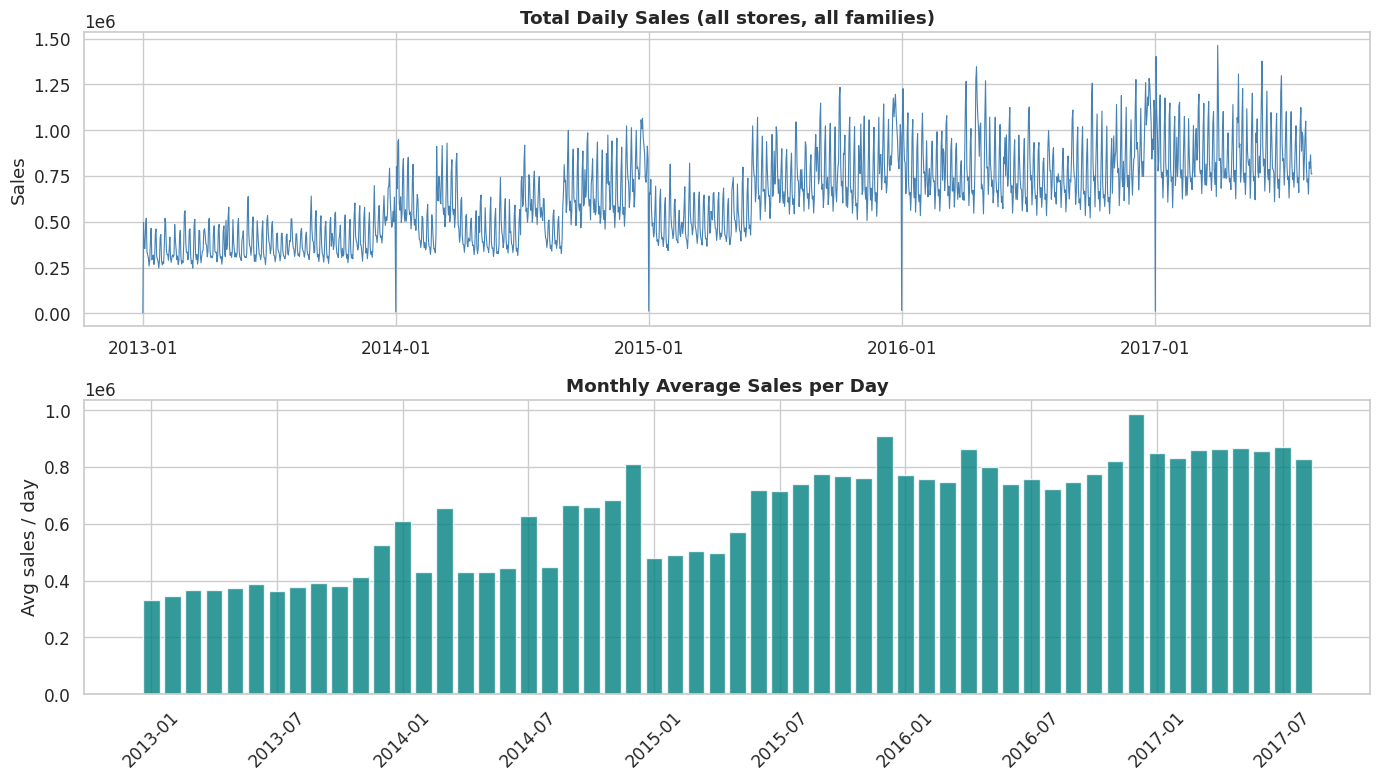

In [26]:
daily_sales = train.groupby("date")["sales"].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily_sales["date"], daily_sales["sales"], lw=0.8, color="steelblue")
axes[0].set_title("Total Daily Sales (all stores, all families)", fontweight="bold")
axes[0].set_ylabel("Sales")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

monthly = daily_sales.copy()
monthly["period"] = monthly["date"].dt.to_period("M").astype(str)
monthly_agg = monthly.groupby("period")["sales"].mean()
axes[1].bar(range(len(monthly_agg)), monthly_agg.values, color="teal", alpha=0.8)
axes[1].set_xticks(range(0, len(monthly_agg), 6))
axes[1].set_xticklabels(monthly_agg.index[::6], rotation=45)
axes[1].set_title("Monthly Average Sales per Day", fontweight="bold")
axes[1].set_ylabel("Avg sales / day")

plt.tight_layout()
plt.show()

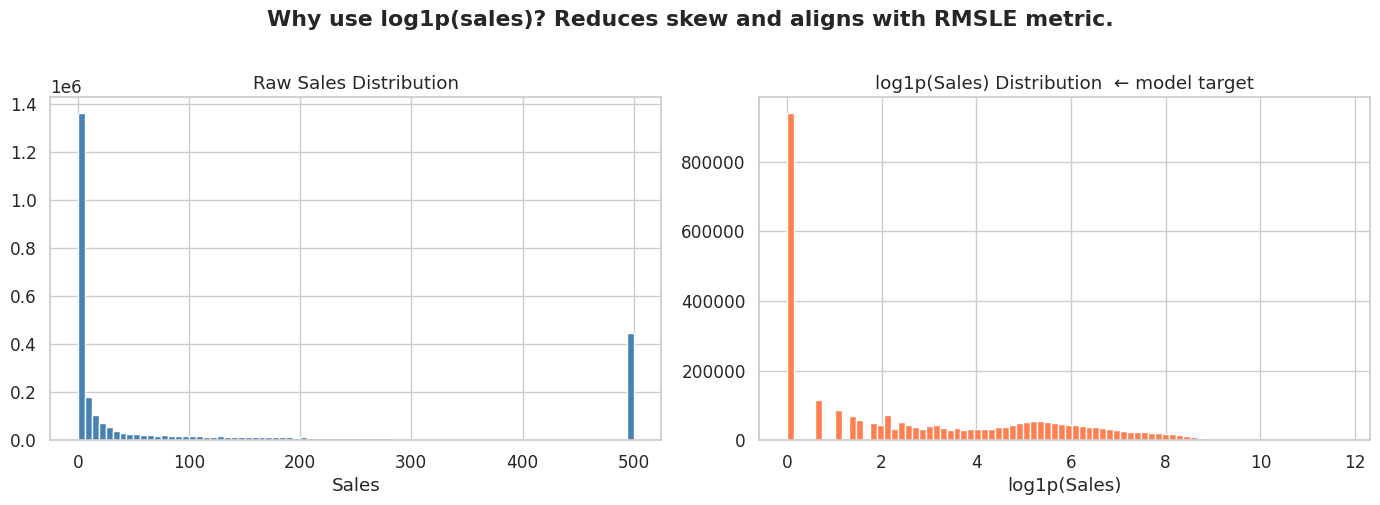

Median: 11.0  |  Mean: 357.8  |  Max: 124717


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train["sales"].clip(0, 500), bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Raw Sales Distribution")
axes[0].set_xlabel("Sales")

axes[1].hist(np.log1p(train["sales"]), bins=80, color="coral", edgecolor="white")
axes[1].set_title("log1p(Sales) Distribution  ← model target")
axes[1].set_xlabel("log1p(Sales)")

plt.suptitle("Why use log1p(sales)? Reduces skew and aligns with RMSLE metric.", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"Median: {train.sales.median():.1f}  |  Mean: {train.sales.mean():.1f}  |  Max: {train.sales.max():.0f}")

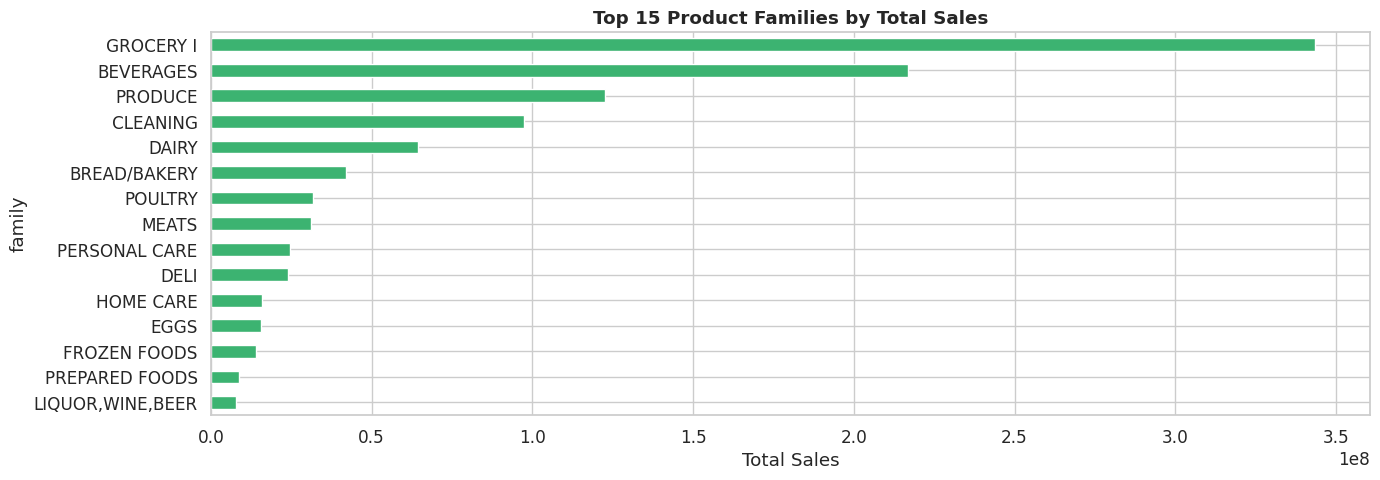

In [28]:
top_families = (
    train.groupby("family")["sales"]
         .sum()
         .sort_values(ascending=False)
         .head(15)
)

plt.figure(figsize=(14, 5))
top_families.plot(kind="barh", color="mediumseagreen", edgecolor="white")
plt.xlabel("Total Sales")
plt.title("Top 15 Product Families by Total Sales", fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

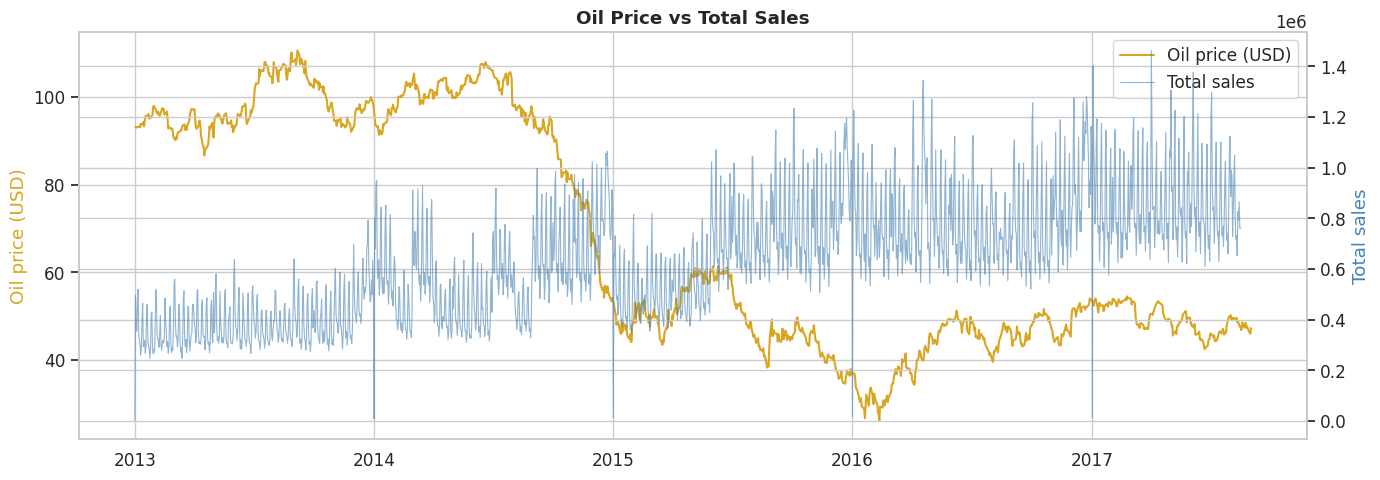

In [29]:
oil_clean = oil.set_index("date")["dcoilwtico"].interpolate().reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(oil_clean["date"], oil_clean["dcoilwtico"], color="goldenrod", lw=1.5, label="Oil price (USD)")
ax2.plot(daily_sales["date"], daily_sales["sales"], color="steelblue", lw=0.8, alpha=0.6, label="Total sales")

ax1.set_ylabel("Oil price (USD)", color="goldenrod")
ax2.set_ylabel("Total sales", color="steelblue")
ax1.set_title("Oil Price vs Total Sales", fontweight="bold")

lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper right")
plt.tight_layout()
plt.show()

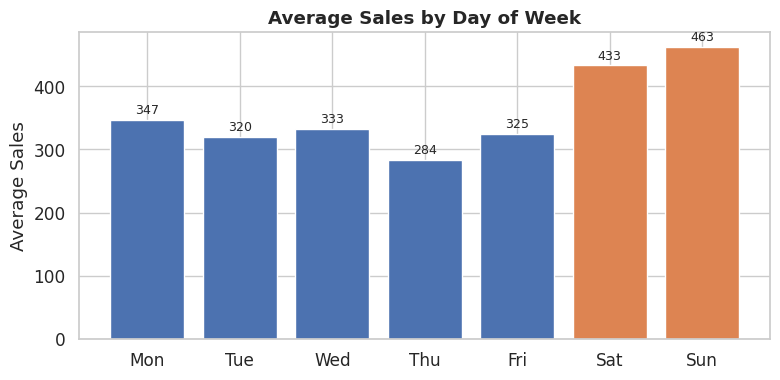

In [30]:
train["dow"] = train["date"].dt.dayofweek
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_sales  = train.groupby("dow")["sales"].mean()

plt.figure(figsize=(8, 4))
colors = ["#4C72B0"] * 5 + ["#DD8452"] * 2
bars = plt.bar(dow_labels, dow_sales.values, color=colors, edgecolor="white")
plt.title("Average Sales by Day of Week", fontweight="bold")
plt.ylabel("Average Sales")
for bar, val in zip(bars, dow_sales.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f"{val:.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()
train.drop(columns=["dow"], inplace=True)

## 4. Feature Engineering

Features built:
- **Time**: year, month, day, day of week, ISO week, quarter, weekend, month start/end
- **Holidays**: national / regional / local counts, transfer flag
- **Oil**: interpolated price + 7-day moving average
- **Sales lags**: lag-1, lag-7, lag-14, lag-28
- **Rolling stats**: 7/14/28-day rolling means + 7-day rolling std
- **Promo lags**: `onpromotion` lag-1, lag-7, lag-14

In [31]:
def build_holiday_features(holidays):
    h = holidays.copy()
    for c in ["type", "locale", "locale_name", "description"]:
        if c in h.columns:
            h[c] = h[c].astype(str)
    h["is_holiday"]  = 1
    h["transferred"] = h["transferred"].fillna(False).astype(int)
    h["is_national"] = (h["locale"].str.lower() == "national").astype(int)
    h["is_regional"] = (h["locale"].str.lower() == "regional").astype(int)
    h["is_local"]    = (h["locale"].str.lower() == "local").astype(int)
    return (
        h.groupby("date", as_index=False)
         .agg(
             holiday_count       = ("is_holiday",  "sum"),
             holiday_transferred = ("transferred", "sum"),
             holiday_national    = ("is_national", "sum"),
             holiday_regional    = ("is_regional", "sum"),
             holiday_local       = ("is_local",    "sum"),
         )
    )

def build_oil_features(oil):
    o = oil.copy().sort_values("date")
    o["dcoilwtico"] = o["dcoilwtico"].interpolate().ffill().bfill()
    o["oil_ma7"]    = o["dcoilwtico"].rolling(7, min_periods=1).mean()
    return o

def build_transaction_features(tx):
    return (
        tx.groupby(["date", "store_nbr"], as_index=False)
          .agg(transactions=("transactions", "sum"))
    )

def add_time_features(df):
    d = df.copy()
    d["year"]           = d["date"].dt.year.astype(np.int16)
    d["month"]          = d["date"].dt.month.astype(np.int8)
    d["day"]            = d["date"].dt.day.astype(np.int8)
    d["dayofweek"]      = d["date"].dt.dayofweek.astype(np.int8)
    d["weekofyear"]     = d["date"].dt.isocalendar().week.astype(np.int16)
    d["quarter"]        = d["date"].dt.quarter.astype(np.int8)
    d["days_in_month"]  = d["date"].dt.days_in_month.astype(np.int8)
    d["is_weekend"]     = (d["dayofweek"] >= 5).astype(np.int8)
    d["is_month_start"] = d["date"].dt.is_month_start.astype(np.int8)
    d["is_month_end"]   = d["date"].dt.is_month_end.astype(np.int8)
    return d

print("Feature engineering functions defined.")

Feature engineering functions defined.


In [32]:
hol_features = build_holiday_features(holidays)
oil_features = build_oil_features(oil)
tx_features  = build_transaction_features(tx)

tr = train.copy(); tr["is_train"] = 1
te = test.copy();  te["is_train"] = 0; te["sales"] = np.nan

full = (
    pd.concat([tr, te], ignore_index=True)
      .sort_values(["date", "store_nbr", "family"])
)

full = full.merge(stores,       on="store_nbr",           how="left")
full = full.merge(oil_features, on="date",                how="left")
full = full.merge(hol_features, on="date",                how="left")
full = full.merge(tx_features,  on=["date", "store_nbr"], how="left")
full = add_time_features(full)

fill_zero = ["dcoilwtico", "oil_ma7", "holiday_count", "holiday_transferred",
             "holiday_national", "holiday_regional", "holiday_local", "transactions"]
for c in fill_zero:
    if c in full.columns:
        full[c] = full[c].fillna(0.0)

full["onpromotion"] = full["onpromotion"].fillna(0).astype(np.int16)

print(f"Full table: {full.shape[0]:,} rows x {full.shape[1]} columns")
display(full.head(3))

Full table: 3,029,400 rows x 29 columns


,id,date,store_nbr,family,sales,onpromotion,is_train,city,state,type,cluster,dcoilwtico,oil_ma7,holiday_count,holiday_transferred,holiday_national,holiday_regional,holiday_local,transactions,year,month,day,dayofweek,weekofyear,quarter,days_in_month,is_weekend,is_month_start,is_month_end
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,1,Quito,Pichincha,D,13,93.140,93.140,1.000,0.000,1.000,0.000,0.000,0.000,2013,1,1,1,1,1,31,0,1,0
1,1,2013-01-01,1,BABY CARE,0.000,0,1,Quito,Pichincha,D,13,93.140,93.140,1.000,0.000,1.000,0.000,0.000,0.000,2013,1,1,1,1,1,31,0,1,0
2,2,2013-01-01,1,BEAUTY,0.000,0,1,Quito,Pichincha,D,13,93.140,93.140,1.000,0.000,1.000,0.000,0.000,0.000,2013,1,1,1,1,1,31,0,1,0


In [34]:
full = full.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)

def add_lag_rolling(df):
    d = df.copy()
    
    for lag in [1, 7, 14, 28]:
        d[f"sales_lag_{lag}"] = d["sales"].shift(lag)
    
    sales_shifted = d["sales"].shift(1)
    for w in [7, 14, 28]:
        d[f"sales_rollmean_{w}"] = sales_shifted.rolling(w, min_periods=1).mean()
    
    d["sales_rollstd_7"] = sales_shifted.rolling(7, min_periods=2).std()
    
    for lag in [1, 7, 14]:
        d[f"promo_lag_{lag}"] = d["onpromotion"].shift(lag)
    
    return d

full = full.groupby(["store_nbr", "family"], group_keys=False).apply(add_lag_rolling)

lag_cols = [c for c in full.columns if "lag_" in c or "roll" in c]
full[lag_cols] = full[lag_cols].fillna(0.0)

print(f"{len(lag_cols)} lag/rolling features added:")
print(lag_cols)

11 lag/rolling features added:
['sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rollmean_7', 'sales_rollmean_14', 'sales_rollmean_28', 'sales_rollstd_7', 'promo_lag_1', 'promo_lag_7', 'promo_lag_14']


## 5. Dataset Preparation

- Time-based split: last 60 days of training data used for validation
- Categorical columns encoded as `category` dtype (for LightGBM)
- Check for remaining missing values

In [35]:
VAL_DAYS = 60

train_df = full[full["is_train"] == 1].copy()
max_date = train_df["date"].max()
cutoff   = max_date - pd.Timedelta(days=VAL_DAYS)

tr = train_df[train_df["date"] <= cutoff].copy()
va = train_df[train_df["date"] >  cutoff].copy()

print(f"Full train : {train_df.date.min().date()} to {train_df.date.max().date()}  ({len(train_df):,} rows)")
print(f"Model train: {tr.date.min().date()} to {tr.date.max().date()}  ({len(tr):,} rows)")
print(f"Validation : {va.date.min().date()} to {va.date.max().date()}  ({len(va):,} rows)")
print(f"Cutoff     : {cutoff.date()}")

Full train : 2013-01-01 to 2017-08-15  (3,000,888 rows)
Model train: 2013-01-01 to 2017-06-16  (2,893,968 rows)
Validation : 2017-06-17 to 2017-08-15  (106,920 rows)
Cutoff     : 2017-06-16


In [36]:
DROP_COLS = ["sales", "is_train", "date"]
CAT_COLS  = [c for c in ["family", "city", "state", "type", "cluster", "store_nbr"] if c in full.columns]
NUM_COLS  = [c for c in train_df.columns if c not in DROP_COLS + CAT_COLS]

print(f"Categorical features ({len(CAT_COLS)}): {CAT_COLS}")
print(f"Numerical features   ({len(NUM_COLS)}): {NUM_COLS[:8]} ...")
print(f"Total features       : {len(CAT_COLS) + len(NUM_COLS)}")

missing = train_df.drop(columns=DROP_COLS).isnull().sum()
missing = missing[missing > 0]
print()
if missing.empty:
    print("No missing values in features.")
else:
    print("Columns with NaN:")
    display(missing.to_frame("count"))

Categorical features (6): ['family', 'city', 'state', 'type', 'cluster', 'store_nbr']
Numerical features   (31): ['id', 'onpromotion', 'dcoilwtico', 'oil_ma7', 'holiday_count', 'holiday_transferred', 'holiday_national', 'holiday_regional'] ...
Total features       : 37

No missing values in features.


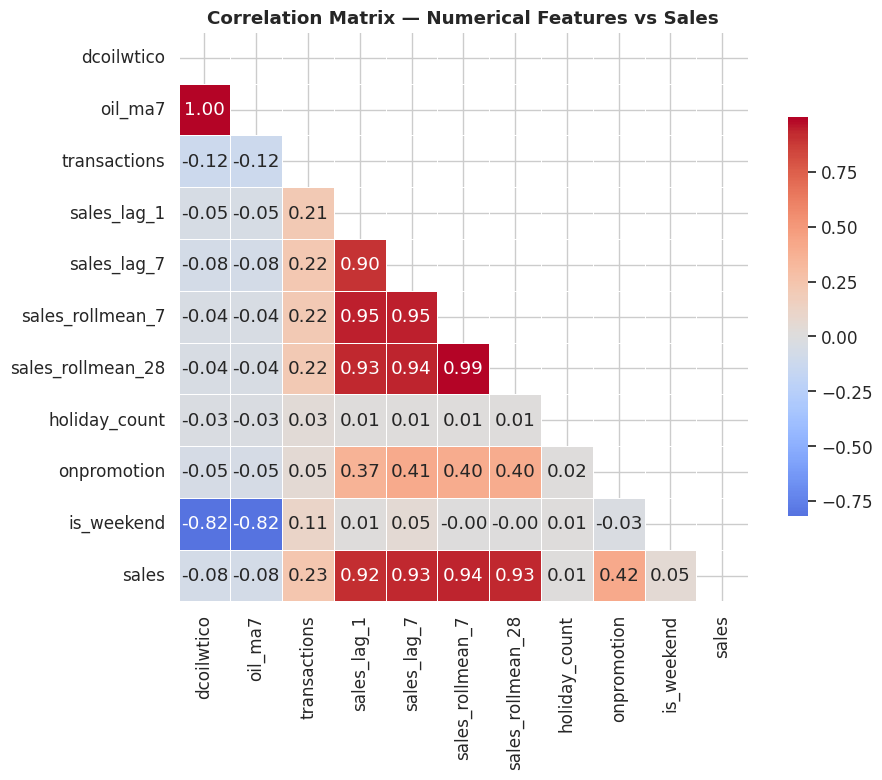

In [37]:
corr_cols = [c for c in ["dcoilwtico", "oil_ma7", "transactions", "sales_lag_1",
                          "sales_lag_7", "sales_rollmean_7", "sales_rollmean_28",
                          "holiday_count", "onpromotion", "is_weekend"] if c in tr.columns]

corr = tr[corr_cols + ["sales"]].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True, cbar_kws={"shrink": 0.7})
plt.title("Correlation Matrix — Numerical Features vs Sales", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Modeling

**LightGBM**  gradient boosted trees, state-of-the-art for tabular forecasting.  
**Ridge** regularized linear regression used as fallback if LightGBM is unavailable.

The model is trained on `log1p(sales)` to reduce skew, handle outliers, and align with the RMSLE metric.

In [38]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

def prepare_xy(df, cat_cols, drop_cols):
    X = df.drop(columns=drop_cols).copy()
    for c in cat_cols:
        if c in X.columns:
            X[c] = X[c].astype("category")
    y = np.log1p(df["sales"].values)
    return X, y

X_tr, y_tr = prepare_xy(tr, CAT_COLS, DROP_COLS)
X_va, y_va = prepare_xy(va, CAT_COLS, DROP_COLS)

print(f"X_tr: {X_tr.shape}   y_tr (log1p): min={y_tr.min():.2f}  max={y_tr.max():.2f}")
print(f"X_va: {X_va.shape}   y_va (log1p): min={y_va.min():.2f}  max={y_va.max():.2f}")

X_tr: (2893968, 37)   y_tr (log1p): min=0.00  max=11.73
X_va: (106920, 37)   y_va (log1p): min=0.00  max=9.96


In [41]:
try:
    import lightgbm as lgb

    lgb_tr  = lgb.Dataset(X_tr, label=y_tr, categorical_feature=CAT_COLS, free_raw_data=False)
    lgb_val = lgb.Dataset(X_va, label=y_va, categorical_feature=CAT_COLS,
                          reference=lgb_tr, free_raw_data=False)

    params = {
        "objective":        "regression",
        "metric":           "rmse",
        "learning_rate":    0.05,
        "num_leaves":       128,
        "min_data_in_leaf": 100,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq":     1,
        "lambda_l1":        0.1,
        "lambda_l2":        0.1,
        "seed":             SEED,
        "verbosity":        -1,
    }

    model = lgb.train(
        params,
        lgb_tr,
        num_boost_round = 5000,
        valid_sets      = [lgb_tr, lgb_val],
        valid_names     = ["train", "valid"],
        callbacks       = [lgb.early_stopping(200), lgb.log_evaluation(200)],
    )

    MODEL_TYPE = "lightgbm"
    print(f"LightGBM trained | Best iteration: {model.best_iteration}")
    print(f"Best validation RMSE: {model.best_score['valid']['rmse']:.5f}")

except ImportError:
    print("LightGBM not installed — using Ridge fallback.")
    pre = ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CAT_COLS),
        ("num", "passthrough", [c for c in X_tr.columns if c not in CAT_COLS]),
    ])
    model = Pipeline([("pre", pre), ("model", Ridge(alpha=1.0, random_state=SEED))])
    model.fit(X_tr, y_tr)
    MODEL_TYPE = "ridge"
    print("Ridge trained.")

Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 0.357568	valid's rmse: 0.372947
[400]	train's rmse: 0.346942	valid's rmse: 0.369078
[600]	train's rmse: 0.341394	valid's rmse: 0.367784
[800]	train's rmse: 0.33713	valid's rmse: 0.366966
[1000]	train's rmse: 0.33356	valid's rmse: 0.366471
[1200]	train's rmse: 0.330464	valid's rmse: 0.366268
[1400]	train's rmse: 0.3275	valid's rmse: 0.366064
[1600]	train's rmse: 0.324647	valid's rmse: 0.365878
[1800]	train's rmse: 0.322109	valid's rmse: 0.365725
[2000]	train's rmse: 0.319727	valid's rmse: 0.365626
Early stopping, best iteration is:
[1960]	train's rmse: 0.320173	valid's rmse: 0.365609
LightGBM trained | Best iteration: 1960
Best validation RMSE: 0.36561


## 7. Evaluation & Diagnostics

In [42]:
if MODEL_TYPE == "lightgbm":
    pred_log = model.predict(X_va, num_iteration=model.best_iteration)
else:
    pred_log = model.predict(X_va)

pred_va   = np.clip(np.expm1(pred_log), 0, None)
score_val = rmsle(va["sales"].values, pred_va)

print(f"{'='*50}")
print(f"  Validation RMSLE (last {VAL_DAYS} days): {score_val:.5f}")
print(f"{'='*50}")
print()
print("  Reference points:")
print("    > 0.50  — Simple baseline")
print("    ~ 0.40  — Decent model")
print("    < 0.30  — Good model")
print("    < 0.20  — Top Kaggle")

  Validation RMSLE (last 60 days): 0.36558

  Reference points:
    > 0.50  — Simple baseline
    ~ 0.40  — Decent model
    < 0.30  — Good model
    < 0.20  — Top Kaggle


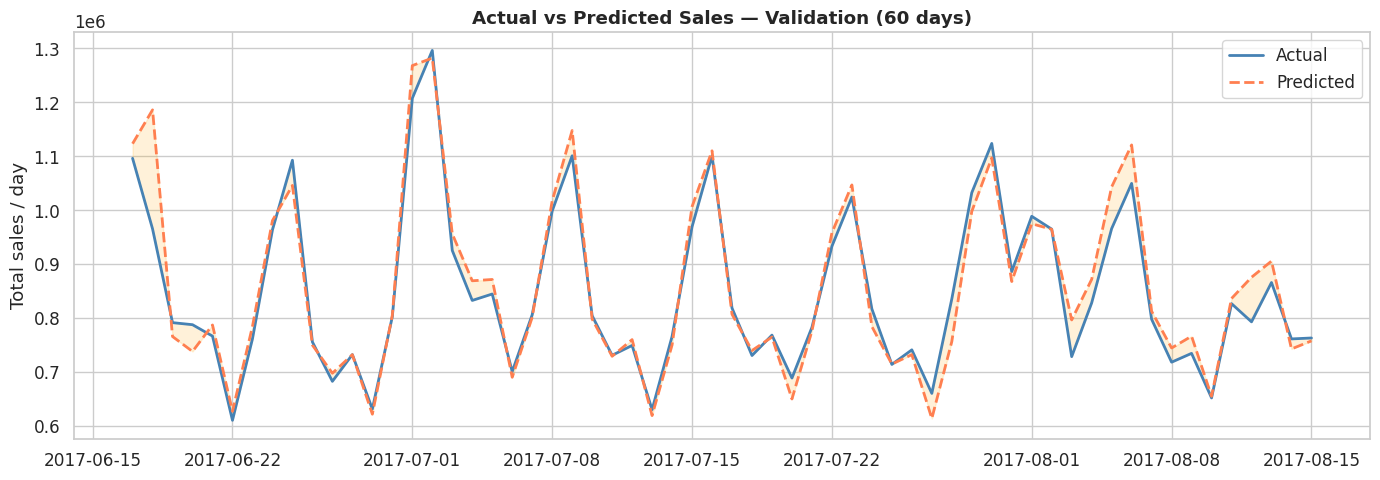

In [43]:
val_results = va[["date", "store_nbr", "family", "sales"]].copy()
val_results["pred"]  = pred_va
val_results["error"] = pred_va - va["sales"].values

daily_val = val_results.groupby("date").agg(
    actual   = ("sales", "sum"),
    predicted = ("pred", "sum")
).reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_val["date"], daily_val["actual"],    label="Actual",    lw=2, color="steelblue")
plt.plot(daily_val["date"], daily_val["predicted"], label="Predicted", lw=2, color="coral", linestyle="--")
plt.fill_between(daily_val["date"], daily_val["actual"], daily_val["predicted"],
                 alpha=0.15, color="orange")
plt.title(f"Actual vs Predicted Sales — Validation ({VAL_DAYS} days)", fontweight="bold")
plt.ylabel("Total sales / day")
plt.legend()
plt.tight_layout()
plt.show()

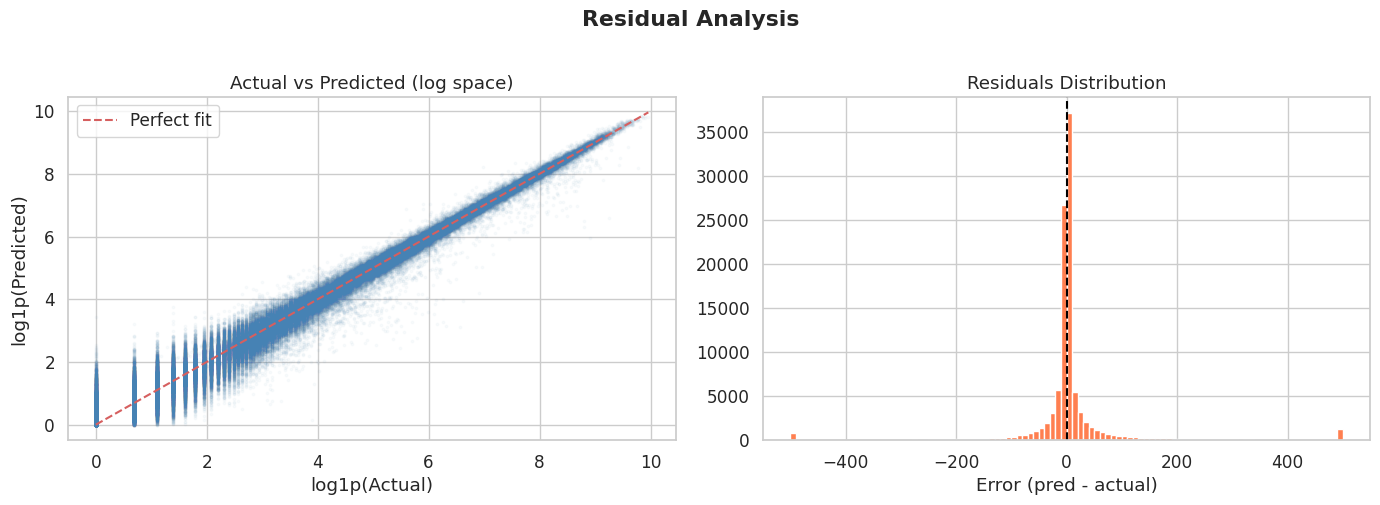

Mean bias : 5.61
MAE       : 50.19


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(np.log1p(val_results["sales"]),
                np.log1p(np.clip(val_results["pred"], 0, None)),
                alpha=0.03, s=3, color="steelblue")
lim = [0, np.log1p(val_results["sales"].max())]
axes[0].plot(lim, lim, "r--", lw=1.5, label="Perfect fit")
axes[0].set_xlabel("log1p(Actual)")
axes[0].set_ylabel("log1p(Predicted)")
axes[0].set_title("Actual vs Predicted (log space)")
axes[0].legend()

axes[1].hist(val_results["error"].clip(-500, 500), bins=100, color="coral", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", lw=1.5)
axes[1].set_title("Residuals Distribution")
axes[1].set_xlabel("Error (pred - actual)")

plt.suptitle("Residual Analysis", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"Mean bias : {val_results.error.mean():.2f}")
print(f"MAE       : {val_results.error.abs().mean():.2f}")

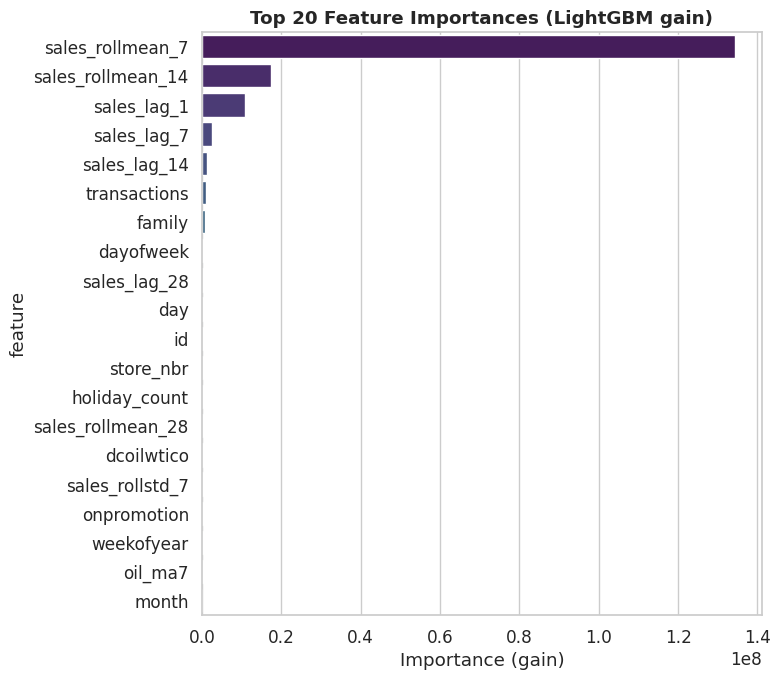

Top 5 features:
          feature    importance
 sales_rollmean_7 134365226.823
sales_rollmean_14  17406379.973
      sales_lag_1  10781888.390
      sales_lag_7   2417487.533
     sales_lag_14   1191886.100


In [45]:
if MODEL_TYPE == "lightgbm":
    fi = (
        pd.DataFrame({
            "feature":    model.feature_name(),
            "importance": model.feature_importance(importance_type="gain"),
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )

    plt.figure(figsize=(8, 7))
    sns.barplot(data=fi, x="importance", y="feature", palette="viridis")
    plt.title("Top 20 Feature Importances (LightGBM gain)", fontweight="bold")
    plt.xlabel("Importance (gain)")
    plt.tight_layout()
    plt.show()

    print("Top 5 features:")
    print(fi.head(5).to_string(index=False))
else:
    print("Feature importance only available with LightGBM.")

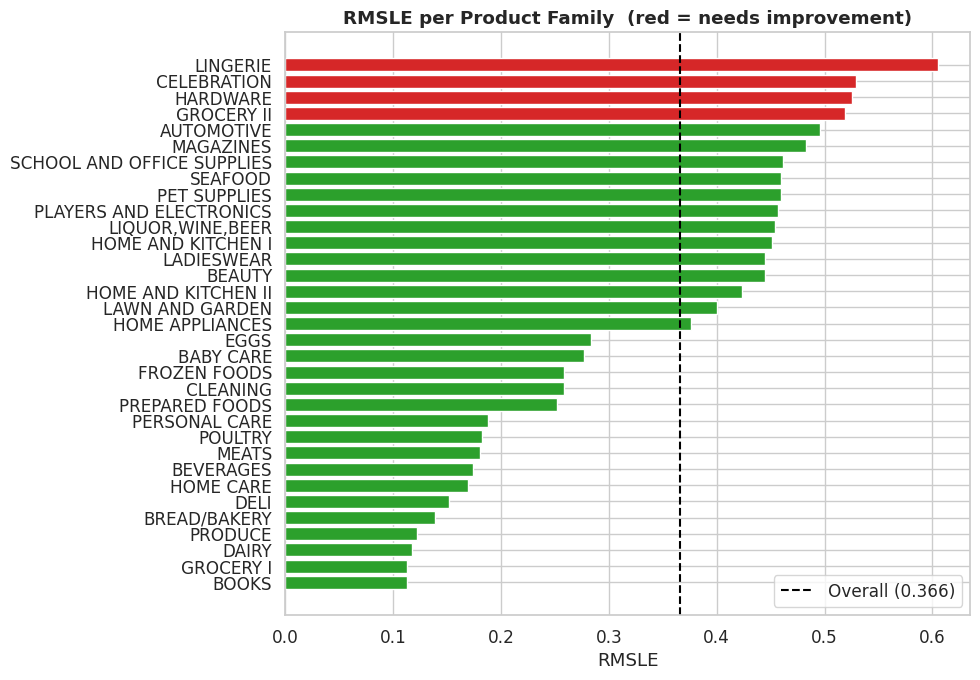

In [46]:
family_scores = []
for fam, grp in val_results.groupby("family"):
    if grp["sales"].sum() > 0:
        s = rmsle(grp["sales"].values, np.clip(grp["pred"].values, 0, None))
        family_scores.append({"family": fam, "rmsle": s})

family_df = pd.DataFrame(family_scores).sort_values("rmsle", ascending=False)

plt.figure(figsize=(10, 7))
colors = ["#d62728" if r > 0.5 else "#2ca02c" for r in family_df["rmsle"]]
plt.barh(family_df["family"], family_df["rmsle"], color=colors, edgecolor="white")
plt.axvline(score_val, color="black", linestyle="--", label=f"Overall ({score_val:.3f})")
plt.xlabel("RMSLE")
plt.title("RMSLE per Product Family  (red = needs improvement)", fontweight="bold")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Submission

In [47]:
test_df = full[full["is_train"] == 0].copy()
X_test  = test_df.drop(columns=["sales", "is_train", "date"]).copy()
for c in CAT_COLS:
    if c in X_test.columns:
        X_test[c] = X_test[c].astype("category")

if MODEL_TYPE == "lightgbm":
    preds_log = model.predict(X_test, num_iteration=model.best_iteration)
else:
    preds_log = model.predict(X_test)

preds = np.clip(np.expm1(preds_log), 0, None)

submission = pd.DataFrame({"id": test_df["id"].values, "sales": preds})
submission.to_csv(SUBMIT_PATH, index=False)

print(f"Submission saved: {SUBMIT_PATH}")
print(f"Rows  : {len(submission):,}")
print(f"Sales — min: {preds.min():.2f}  |  max: {preds.max():.2f}  |  mean: {preds.mean():.2f}")
display(submission.head(10))

Submission saved: /home/guest/Documents/ML_INTERNS/store-sales-time-series-forecasting/submission.csv
Rows  : 28,512
Sales — min: 0.00  |  max: 3629.07  |  mean: 14.12


,id,sales
0,3000888,0.189
1,3002670,0.240
2,3004452,0.265
3,3006234,0.841
4,3008016,0.634
5,3009798,0.173
6,3011580,0.423
7,3013362,0.117
8,3015144,0.155
9,3016926,0.210


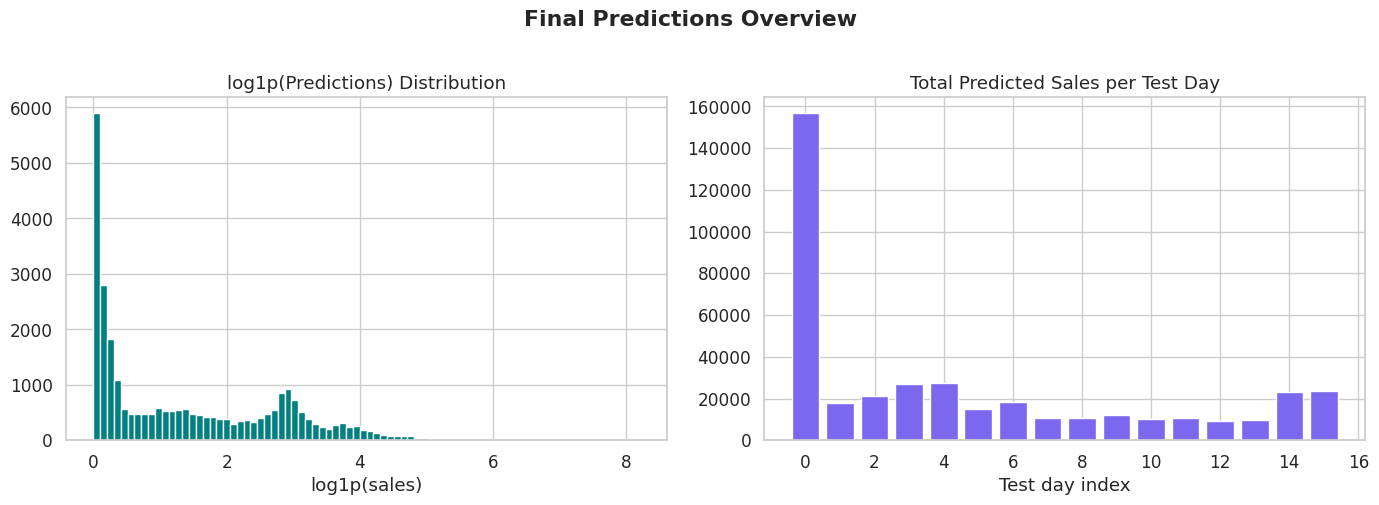

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log1p(preds), bins=80, color="teal", edgecolor="white")
axes[0].set_title("log1p(Predictions) Distribution")
axes[0].set_xlabel("log1p(sales)")

date_arr    = test_df["date"].values
daily_preds = pd.Series(preds, index=date_arr).groupby(level=0).sum()
axes[1].bar(range(len(daily_preds)), daily_preds.values, color="mediumslateblue", edgecolor="white")
axes[1].set_xlabel("Test day index")
axes[1].set_title("Total Predicted Sales per Test Day")

plt.suptitle("Final Predictions Overview", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()